In [19]:
import os
import pandas as pd
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np


MERGES = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/ducb/merges_no_ws'
NO_MERGES = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/ducb/no_merges_no_ws'
POST_MERGES = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/ducb/post_merges_no_ws'
POST_MERGES_NO_MERGES = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/ducb/post_merges_no_merges_no_ws'

In [20]:
def load_edges(root_pth):
    edge_csv_pths = [os.path.join(root_pth, f) for f in os.listdir(root_pth) if f.endswith('.csv')]
    edge_csvs = []
    for edge_csv_pth in edge_csv_pths:
        edge_csv = pd.read_csv(edge_csv_pth, dtype={'error_type': str}, keep_default_na=False)
        edge_csv['ds_name'] = os.path.basename(edge_csv_pth).replace('_all_edges_with_errors.csv', '')
        edge_csvs.append(edge_csv)

    all_edges = pd.concat(edge_csvs, ignore_index=True)
    return all_edges

In [21]:
def plot(all_edges):
    sol_edges = all_edges[all_edges.flow > 0]
    ds_names = sol_edges.groupby('ds_name').size().sort_values(ascending=False).index.tolist()
    grid = sns.FacetGrid(sol_edges, col="ds_name", col_wrap=3, height=4, sharex=False, sharey=False, col_order=ds_names)
    palette = sns.color_palette()
    linestyles = [
        'solid',
        'dashed',
        'dotted',
        'dashdot',
        (0, (3, 1, 1, 1)),
        (0, (5, 1))
    ]
    feature_names = [
        'bandit',
        'cost',
        'softmax_entropy',
        'sensitivity_diff',
        'softmax',
        'parental_softmax'
    ]
    for i, ds_name in enumerate(ds_names):
        ax = grid.axes[i]
        ds_edges = sol_edges[sol_edges['ds_name'] == ds_name]
        dist_sorted = ds_edges.sort_values(by='cost', ascending=False)
        entropy_sorted = ds_edges.sort_values(by='softmax_entropy', ascending=False)
        sens_sorted = ds_edges.sort_values(by='sensitivity_diff')
        p_sorted = ds_edges.sort_values(by='softmax')
        parental_sorted = ds_edges.sort_values(by='parental_softmax')
        bandit_sorted = ds_edges.sort_values(by='bandit_rank')
        for j, feature_sorted in enumerate([
            bandit_sorted,
            dist_sorted,
            entropy_sorted,
            sens_sorted,
            p_sorted,
            parental_sorted
        ]):
            rolling_incorrect = feature_sorted.solution_incorrect.cumsum()
            ax.plot(np.arange(len(rolling_incorrect)), rolling_incorrect, color=palette[j], linestyle=linestyles[j], label=feature_names[j])

    custom_lines = [
        Line2D([0], [0], color=palette[0], lw=2, linestyle=linestyles[0]),
        Line2D([0], [0], color=palette[1], lw=2, linestyle=linestyles[1]),
        Line2D([0], [0], color=palette[2], lw=2, linestyle=linestyles[2]),
        Line2D([0], [0], color=palette[3], lw=2, linestyle=linestyles[3]),
        Line2D([0], [0], color=palette[4], lw=2, linestyle=linestyles[4]),
        Line2D([0], [0], color=palette[5], lw=2, linestyle=linestyles[5]),
    ]
    grid.figure.legend(custom_lines, feature_names)

## NOTE: We are plotting edges with no exit edges, as DBMC-based features are undefined for exit edges, as they're always looking at the parent. All solutions treat WS edges as correct.

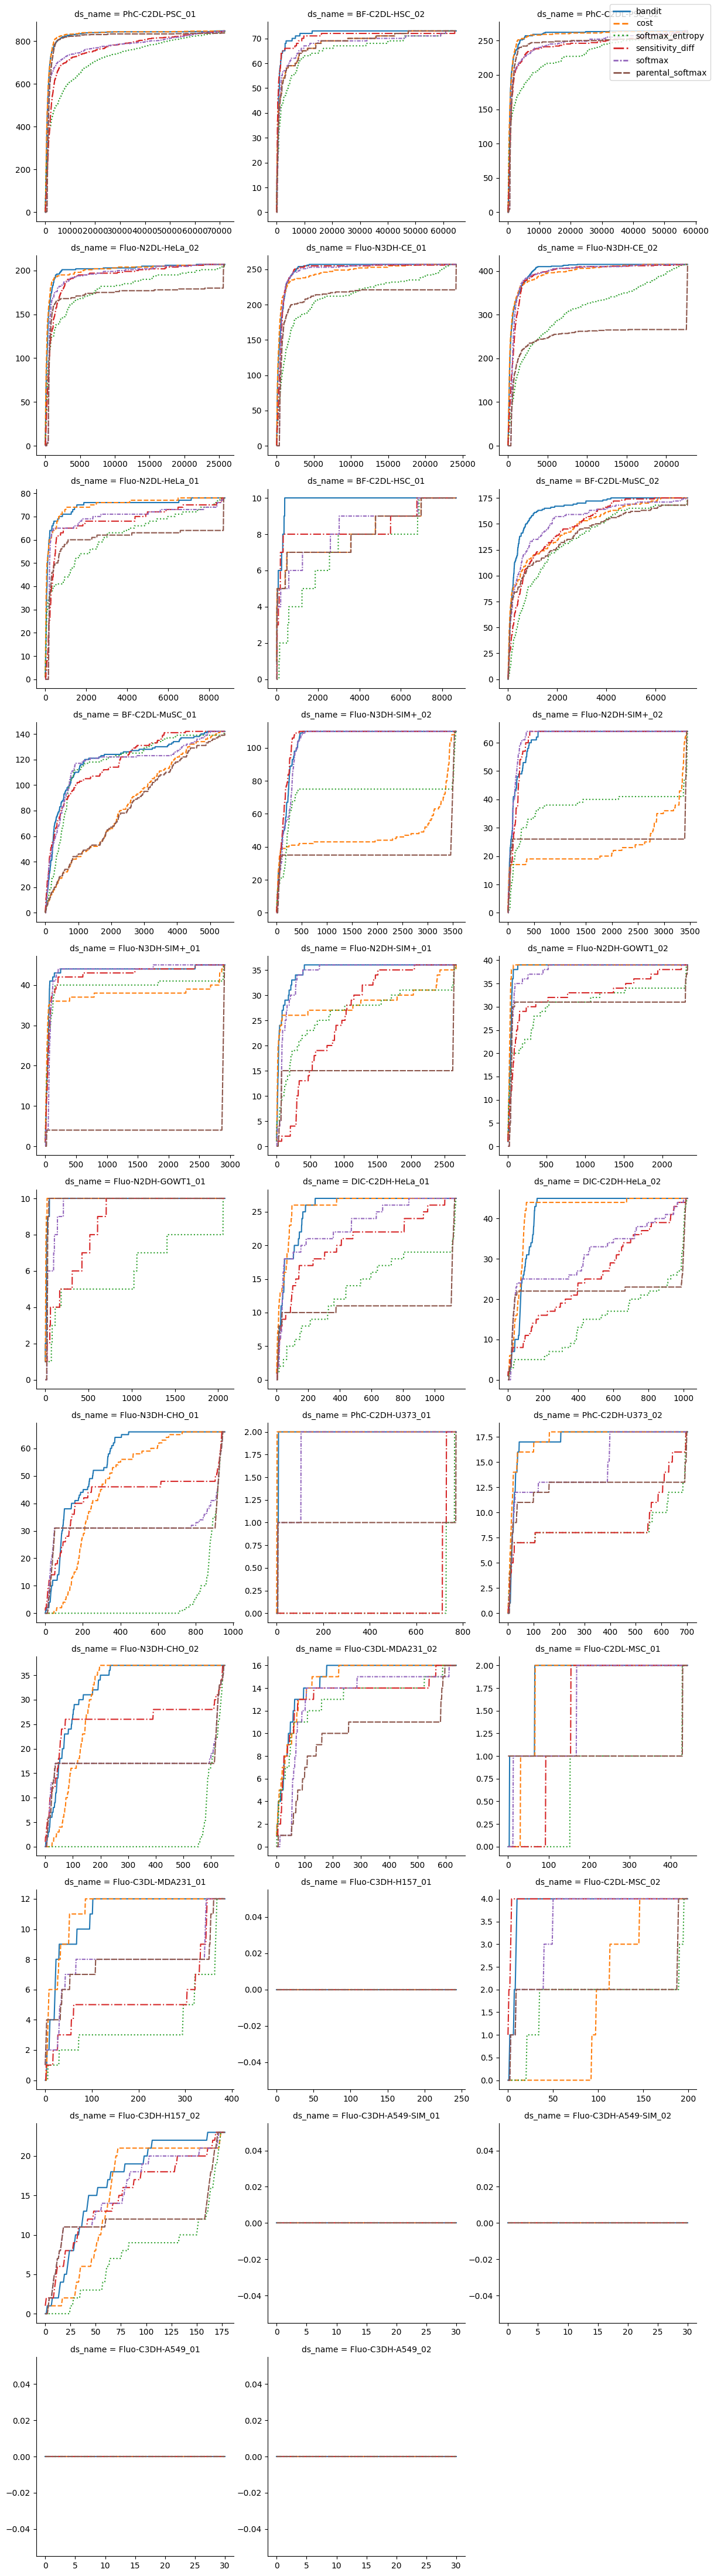

In [22]:
all_edges_w_merges = load_edges(MERGES)
all_edges_w_merges_no_exit = all_edges_w_merges[(all_edges_w_merges.u >= 0) | (all_edges_w_merges.u == -2) & (all_edges_w_merges.v >= 0)]
plot(all_edges_w_merges_no_exit)

In [18]:
all_edges_w_merges_no_exit.error_type.value_counts()

error_type
           3374256
Correct     320623
FA             562
FE             195
WS              71
FP              64
Name: count, dtype: int64